In [1]:
from Alzheimer_Cognitive_fonctions import *

In [2]:
class AlzheimerAnalysisPipeline:
    """
    Pipeline complet pour l’analyse cognitive Alzheimer
    """

    def __init__(self, filepath):
        """
        Initialiser le pipeline d’analyse
        """
        self.filepath = filepath
        self.df = None
        self.df_clean = None
        self.X_train_scaled = None
        self.X_test_scaled = None
        self.y_train = None
        self.y_test = None
        self.scaler = None
        self.selected_features = None
        self.results = {}
        self.comparison_df = None
        self.best_model_name = None

    def run_complete_analysis(self, remove_outliers_flag=False,
                              optimize_hyperparams=True, show_plots=True):
        """
        Exécuter le pipeline d’analyse complet (sans sauvegarde de fichiers)
        """
        print("=" * 80)
        print("PIPELINE D’ANALYSE COGNITIVE ALZHEIMER")
        print("=" * 80)

        # Étape 1 : Chargement et pré-traitement
        print("\nÉTAPE 1 : Chargement et pré-traitement des données")
        self._load_and_preprocess_data()

        # Étape 2 : Qualité des données
        print("\nÉTAPE 2 : Évaluation de la qualité des données")
        self._assess_data_quality(remove_outliers_flag)

        # Étape 3 : Analyse exploratoire
        print("\nÉTAPE 3 : Analyse exploratoire des données")
        self._perform_eda(show_plots)

        # Étape 4 : Division et mise à l’échelle
        print("\nÉTAPE 4 : Division et mise à l’échelle des données")
        self._split_and_scale_data()

        # Étape 5 : Sélection des caractéristiques
        print("\nÉTAPE 5 : Sélection des caractéristiques")
        self._perform_feature_selection(show_plots)

        # Étape 6 : Entraînement et évaluation
        print("\nÉTAPE 6 : Entraînement et évaluation des modèles")
        self._train_and_evaluate_models()

        # Étape 7 : Optimisation des hyperparamètres
        if optimize_hyperparams:
            print("\nÉTAPE 7 : Optimisation des hyperparamètres")
            self._optimize_hyperparameters()

        # Étape 8 : Comparaison et analyse
        print("\nÉTAPE 8 : Comparaison et analyse des résultats")
        self._compare_and_analyze_results(show_plots)

        print("\nANALYSE TERMINÉE AVEC SUCCÈS !")
        print("=" * 80)

    #  Fonctions Originales 
    def _load_and_preprocess_data(self):
        self.df = load_alzheimer_data(self.filepath)
        if self.df is None:
            raise ValueError("Échec du chargement du jeu de données")
        self.df_clean = preprocess_data(self.df)

    def _assess_data_quality(self, remove_outliers_flag):
        check_data_quality(self.df_clean)
        outlier_indices = detect_outliers_iqr(self.df_clean)
        if remove_outliers_flag and outlier_indices:
            self.df_clean = remove_outliers(self.df_clean, outlier_indices)

    def _perform_eda(self, show_plots):
        y = self.df_clean['Diagnosis']
        analyze_target_distribution(y)
        if show_plots:
            plot_feature_distributions(self.df_clean)
            plot_correlation_heatmap(self.df_clean)

    def _split_and_scale_data(self):
        X = self.df_clean.drop(columns=['Diagnosis'])
        y = self.df_clean['Diagnosis']
        (self.X_train_scaled, self.X_test_scaled,
         self.y_train, self.y_test, self.scaler) = split_and_scale_data(X, y)

    def _perform_feature_selection(self, show_plots):
        corr_features = select_features_by_correlation(self.X_train_scaled, self.y_train)
        rf_features, _ = select_features_by_rf_importance(self.X_train_scaled, self.y_train)
        anova_features, _ = select_features_by_anova(self.X_train_scaled, self.y_train)
        self.selected_features = combine_selected_features(
            corr_features, rf_features, anova_features
        )
        self.X_train_selected = self.X_train_scaled[self.selected_features]
        self.X_test_selected = self.X_test_scaled[self.selected_features]

    def _train_and_evaluate_models(self):
        models = get_default_models()
        self.baseline_results = evaluate_multiple_models(
            models, self.X_train_selected, self.y_train,
            self.X_test_selected, self.y_test
        )
        self.results.update(self.baseline_results)

    def _optimize_hyperparameters(self):
        models = get_default_models()
        param_grids = get_default_param_grids()
        self.optimized_results = optimize_all_models(
            models, param_grids, self.X_train_selected,
            self.y_train, self.X_test_selected, self.y_test
        )
        self.results.update(self.optimized_results)

    def _compare_and_analyze_results(self, show_plots):
        comparison_results = self.optimized_results if hasattr(self, 'optimized_results') else self.baseline_results
        self.comparison_df = create_comparison_dataframe(comparison_results)
        self.best_model_name, _ = find_best_model(self.comparison_df)
        if show_plots:
            plot_model_comparison(self.comparison_df)
        print_summary_report(self.comparison_df, self.best_model_name)

    def get_best_model(self):
        return self.results[self.best_model_name]['model'] if self.best_model_name else None

    def predict_new_data(self, new_data):
        best_model = self.get_best_model()
        if best_model is None:
            raise ValueError("Aucun modèle entraîné disponible")
        new_scaled = pd.DataFrame(self.scaler.transform(new_data), columns=new_data.columns)
        return best_model.predict(new_scaled[self.selected_features]), \
               best_model.predict_proba(new_scaled[self.selected_features])


PIPELINE D’ANALYSE COGNITIVE ALZHEIMER

ÉTAPE 1 : Chargement et pré-traitement des données
Jeu de données chargé avec succès. Forme : (2149, 35)
Forme du jeu de données après pré-traitement : (2149, 33)
Colonnes supprimées : ['PatientID', 'DoctorInCharge']

ÉTAPE 2 : Évaluation de la qualité des données
Rapport de qualité des données :
Forme : (2149, 33)
Valeurs manquantes :
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
Ch

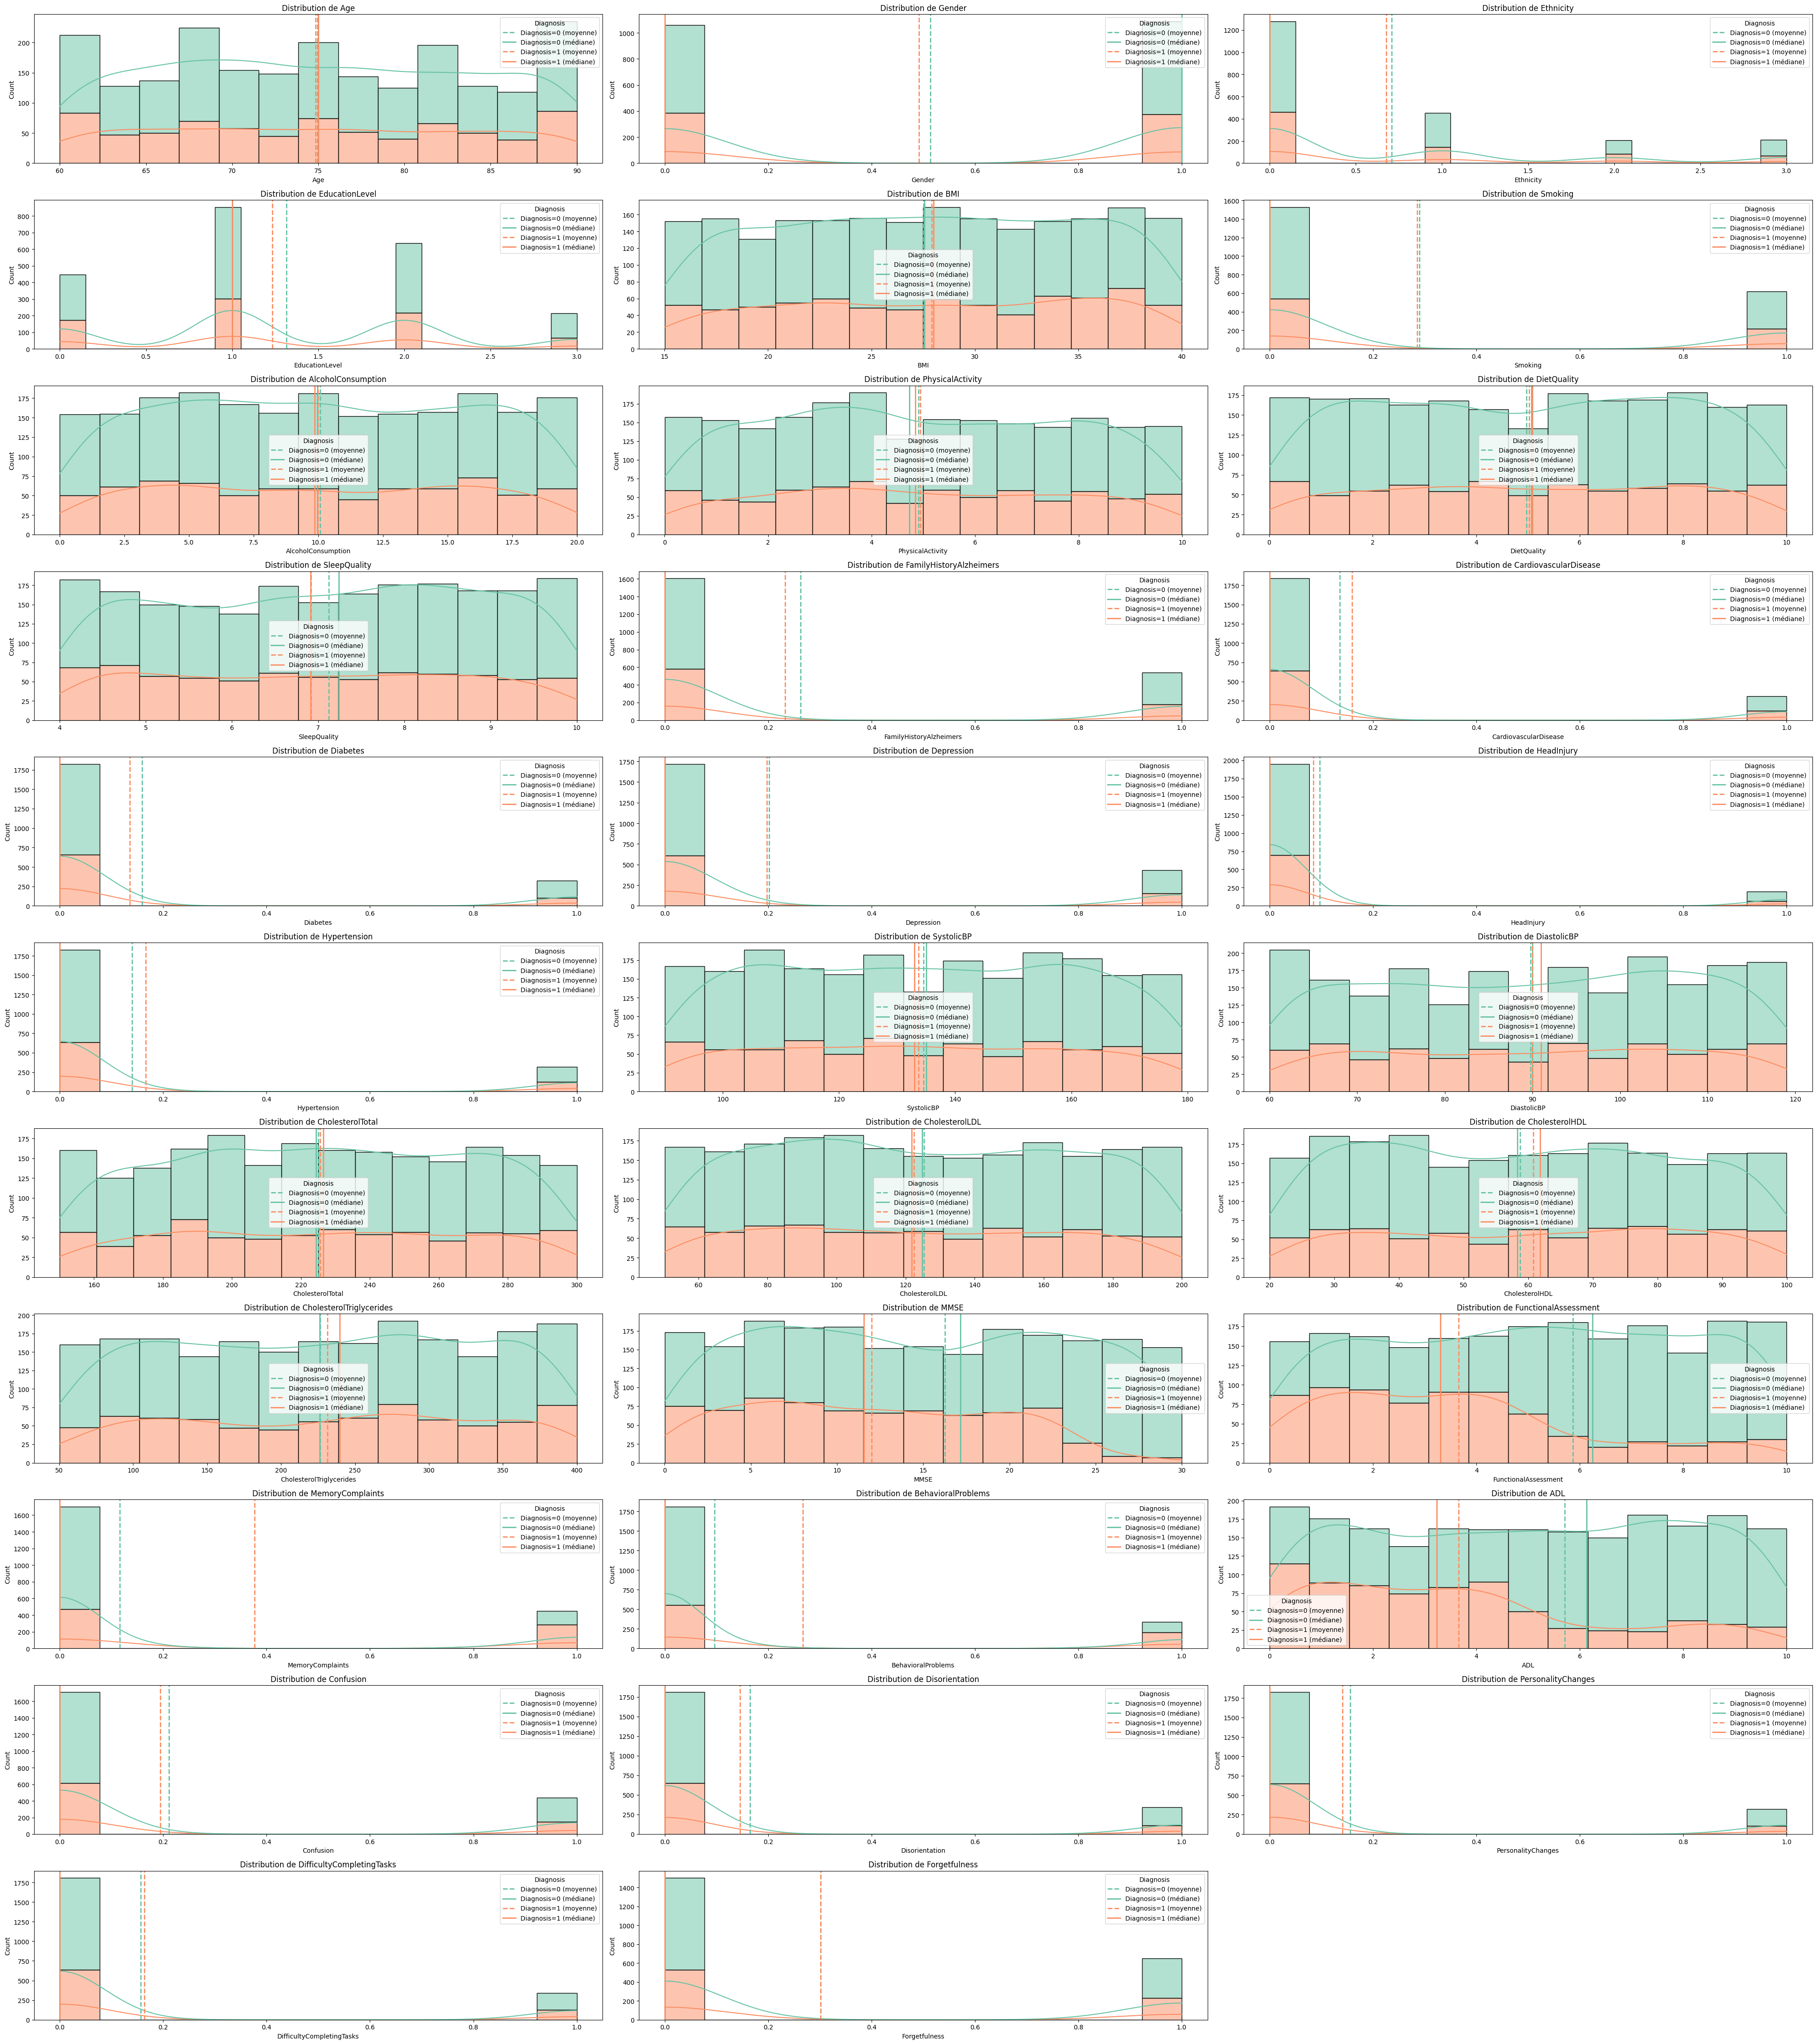

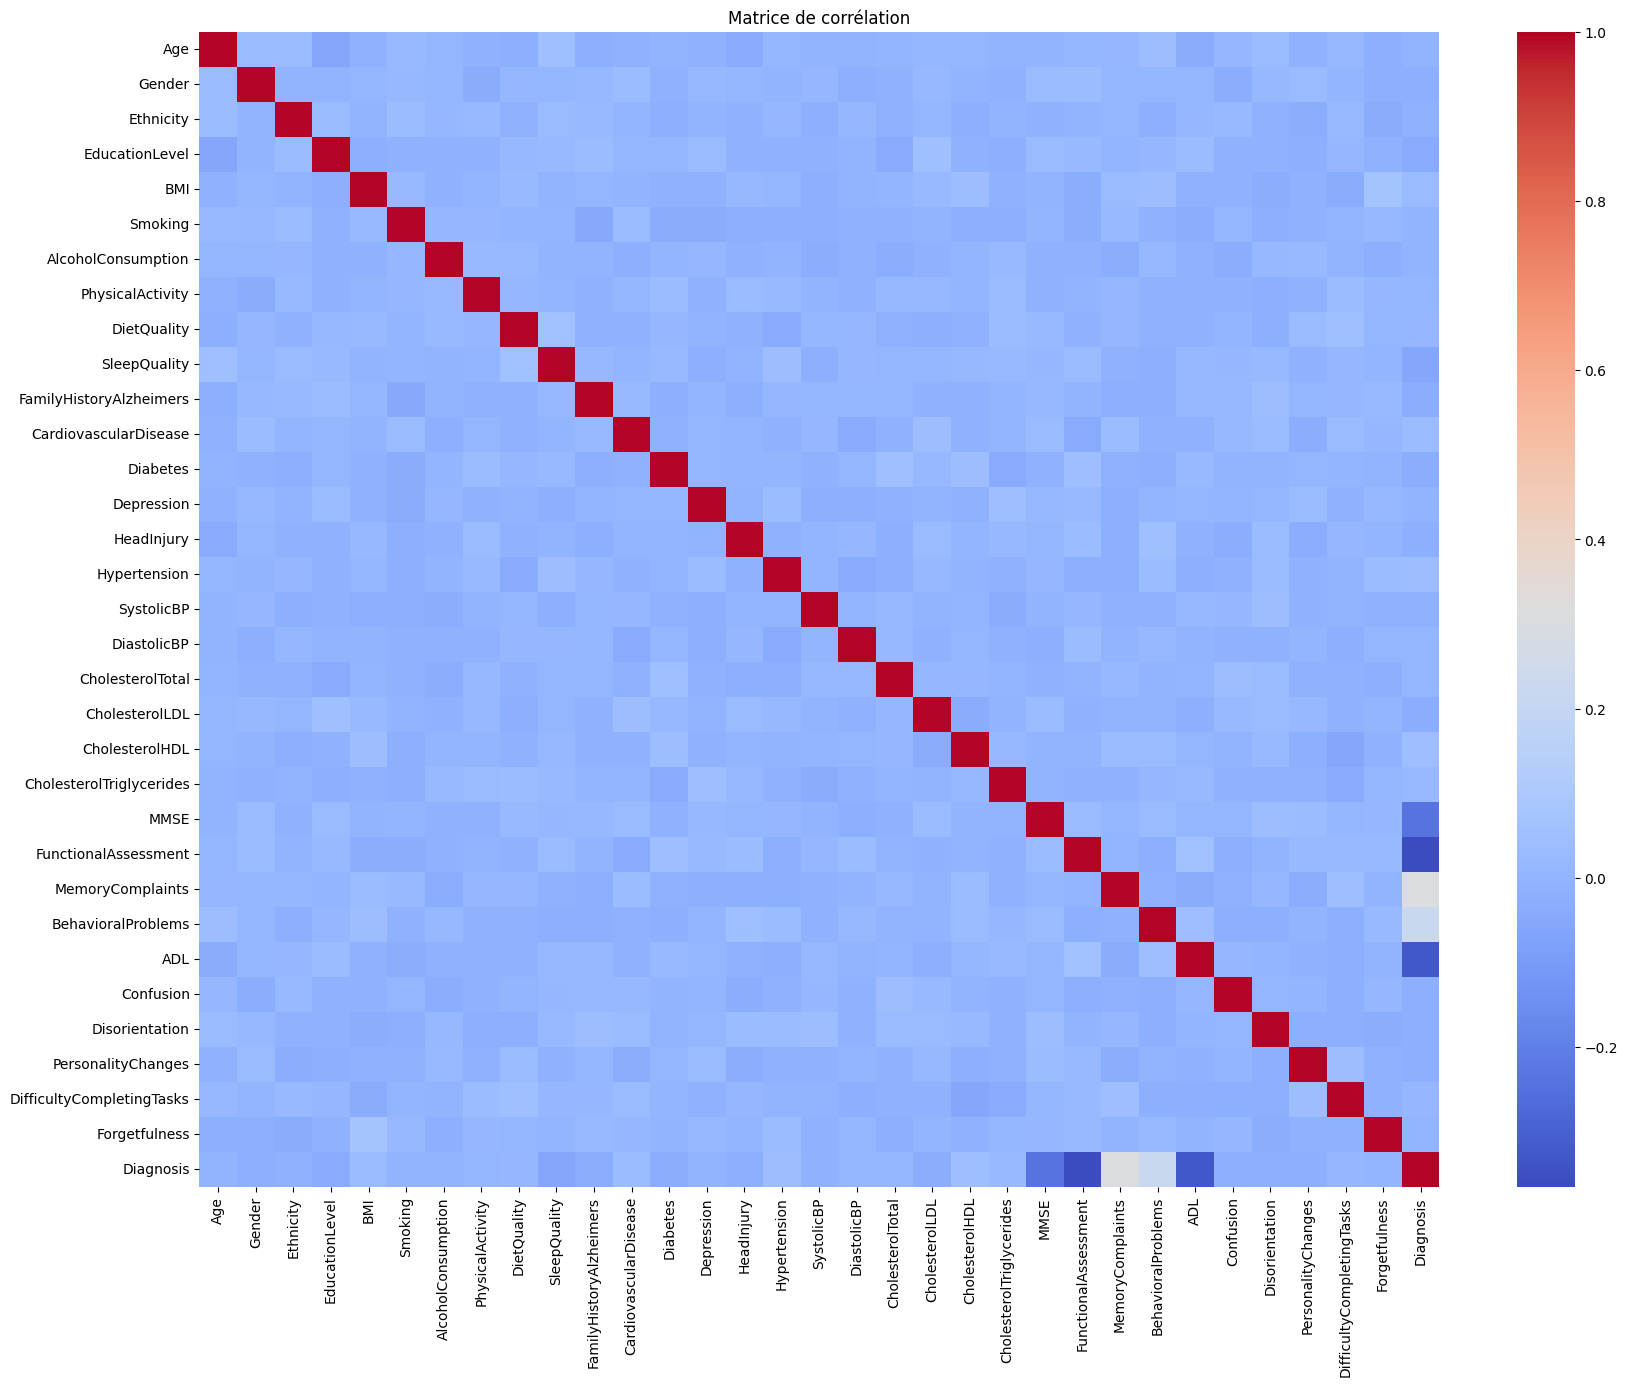


ÉTAPE 4 : Division et mise à l’échelle des données
Forme de l’ensemble d’entraînement : (1719, 32)
Forme de l’ensemble de test : (430, 32)

ÉTAPE 5 : Sélection des caractéristiques
Caractéristiques sélectionnées par corrélation (|r| > 0.1) : 0
[]
Caractéristiques sélectionnées par importance RF (> 0.02) : 17
['FunctionalAssessment', 'ADL', 'MMSE', 'MemoryComplaints', 'BehavioralProblems', 'DietQuality', 'CholesterolTriglycerides', 'BMI', 'CholesterolTotal', 'PhysicalActivity', 'CholesterolLDL', 'CholesterolHDL', 'AlcoholConsumption', 'SleepQuality', 'SystolicBP', 'Age', 'DiastolicBP']


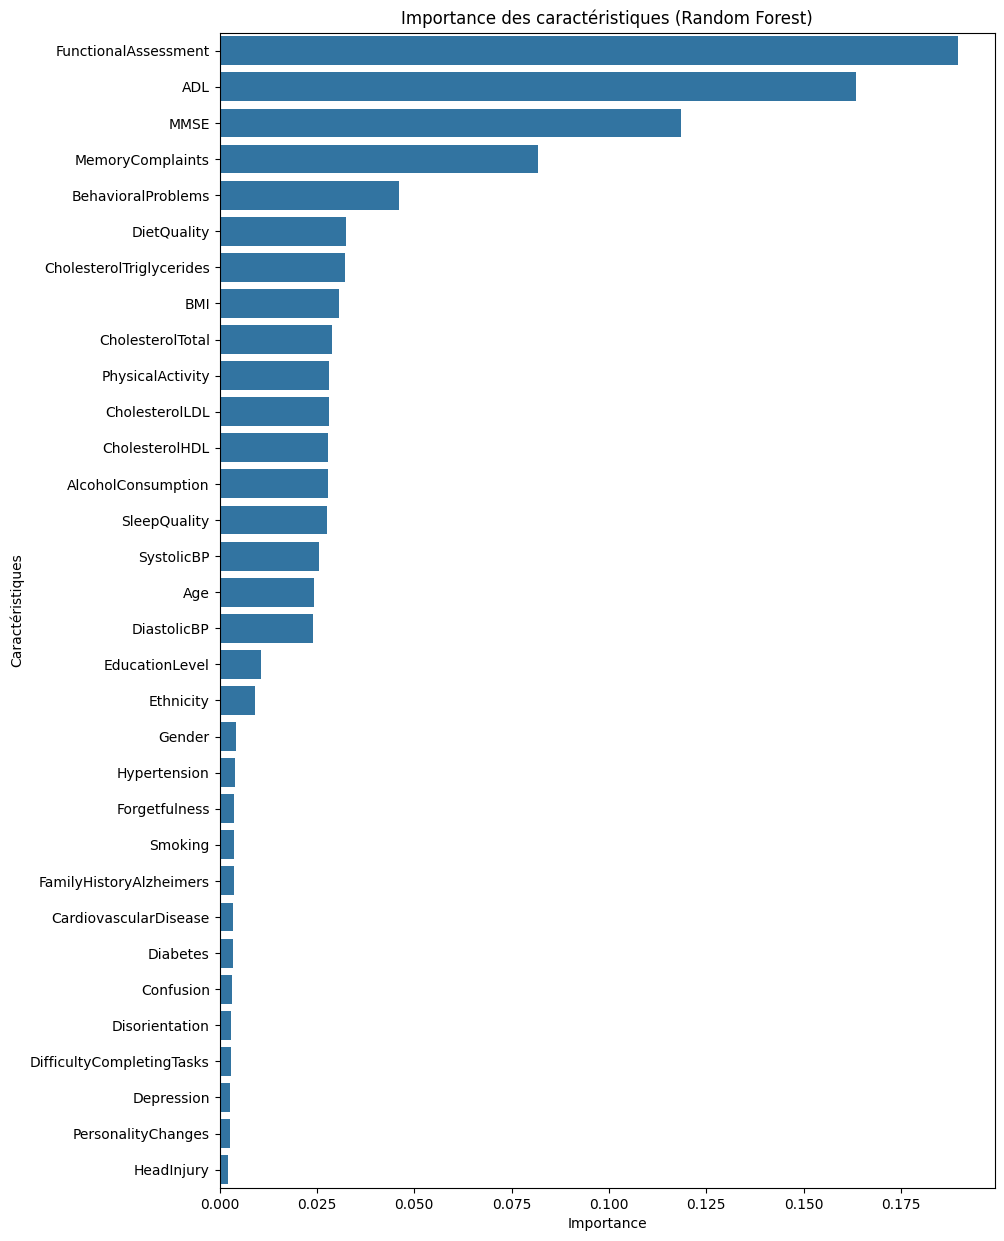

Caractéristiques sélectionnées par ANOVA (F-score > 10) : 5
['FunctionalAssessment', 'ADL', 'MemoryComplaints', 'MMSE', 'BehavioralProblems']


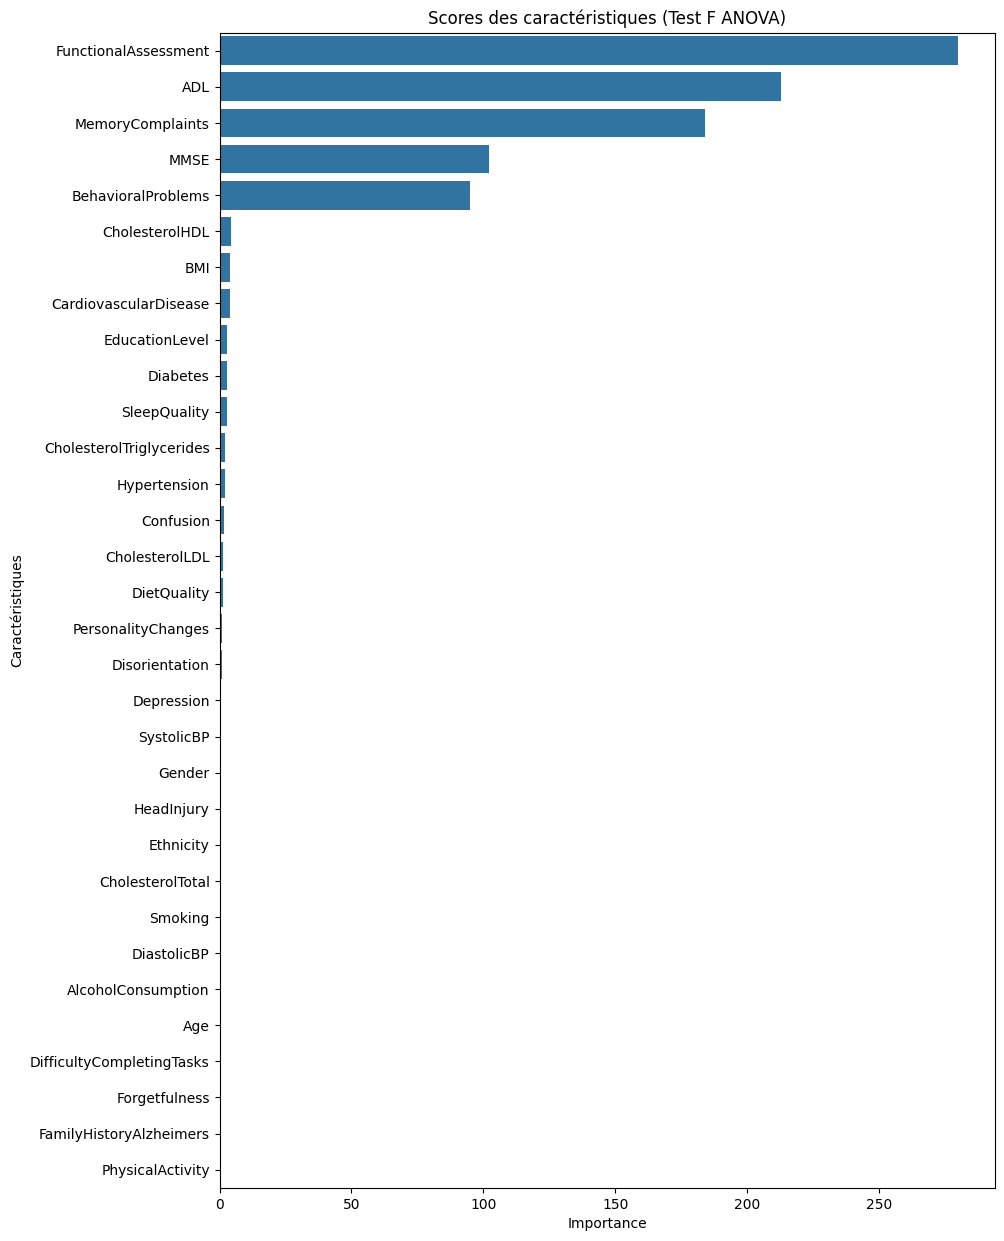

Total de caractéristiques uniques après combinaison : 17
['FunctionalAssessment', 'ADL', 'MMSE', 'MemoryComplaints', 'BehavioralProblems', 'DietQuality', 'CholesterolTriglycerides', 'BMI', 'CholesterolTotal', 'PhysicalActivity', 'CholesterolLDL', 'CholesterolHDL', 'AlcoholConsumption', 'SleepQuality', 'SystolicBP', 'Age', 'DiastolicBP']

ÉTAPE 6 : Entraînement et évaluation des modèles

Entraînement et évaluation de Régression Logistique

Résultats pour Régression Logistique :
Accuracy : 0.8209
Précision : 0.7737
Rappel : 0.6974
Score F1 : 0.7336

Rapport de classification :
              precision    recall  f1-score   support

           0       0.84      0.89      0.87       278
           1       0.77      0.70      0.73       152

    accuracy                           0.82       430
   macro avg       0.81      0.79      0.80       430
weighted avg       0.82      0.82      0.82       430


Matrice de confusion :
[[247  31]
 [ 46 106]]

Entraînement et évaluation de Forêt Aléatoi

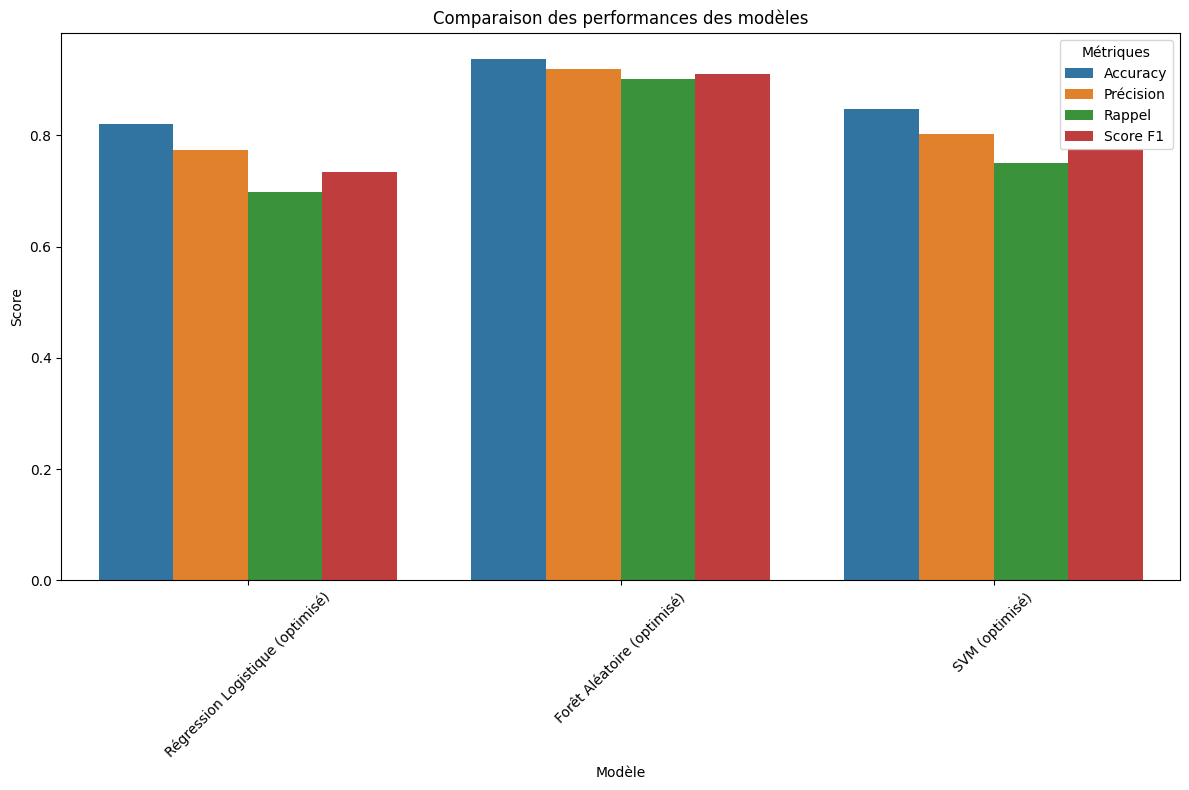


ANALYSE COGNITIVE ALZHEIMER - RAPPORT RÉCAPITULATIF

Nombre de modèles évalués : 3

Meilleur modèle : Forêt Aléatoire (optimisé)

Résumé des performances des modèles :
                             Modèle  Accuracy  Précision  Rappel  Score F1
0  Régression Logistique (optimisé)    0.8209     0.7737  0.6974    0.7336
1        Forêt Aléatoire (optimisé)    0.9372     0.9195  0.9013    0.9103
2                    SVM (optimisé)    0.8465     0.8028  0.7500    0.7755

Statistiques de performance :
Score F1 moyen : 0.8065
Meilleur score F1 : 0.9103
Pire score F1 : 0.7336
Écart-type : 0.0923


ANALYSE TERMINÉE AVEC SUCCÈS !


In [3]:
# === Lancement ===
if __name__ == "__main__":
    try:
        pipeline = AlzheimerAnalysisPipeline("alzheimers_disease_data.csv")
        pipeline.run_complete_analysis(remove_outliers_flag=False,
                                       optimize_hyperparams=True,
                                       show_plots=True)
    except Exception as e:
        print(f"Erreur : {e}")